# AmpleHate-Vi++ on VOZ-HSD: PhoBERT Proposed

Implements **AmpleHate-Vi++** on the VOZ-HSD Vietnamese hate-speech dataset with:
1. Vietnamese NER (`NlpHUST/ner-vietnamese-electra-base`) + target cue lexicon
2. Separate attack cue bank (offensive predicates)
3. Relation Bank: 3 HeadAttention modules (r_exp, r_imp, r_atk) fused via Linear
4. Instance-adaptive gate `g = sigmoid(W [h_CLS; r])` replacing fixed scalar `e`
5. CrossEntropy (weighted) + ContrastiveLoss (alpha=0.1)
6. VOZ-HSD loading/sampling/splitting follows the baseline notebook


In [1]:
!pip install transformers datasets sentencepiece huggingface_hub underthesea easydict -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 56.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.8 MB/s eta 0:00:00


In [2]:
import os, re, time, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, pipeline

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() > 2 else 0

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Workers: {NUM_WORKERS} | Pin memory: {PIN_MEMORY}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Workers: 2 | Pin memory: True


In [3]:
MODEL_NAME  = 'vinai/phobert-base'
NER_MODEL   = 'NlpHUST/ner-vietnamese-electra-base'
MAX_LEN     = 256
HIDDEN_DIM  = 768
HEAD_DIM    = HIDDEN_DIM

BATCH_SIZE      = 32
NUM_EPOCHS      = 8
LR              = 2e-5
HEAD_LR         = 5e-5
WARMUP_RATIO    = 0.06
DROPOUT         = 0.1
PATIENCE        = 2
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.05
GRAD_ACCUM      = 2       # effective batch = 32
ALPHA_CL        = 0.1     # contrastive loss weight
USE_NER_AT_EVAL = True    # keep target extraction consistent across train/val/test

SAMPLE_SIZE  = 40_000
RANDOM_STATE = 42

NUM_CLASSES = 2
LABEL_NAMES = ['NON-HATE', 'HATE']
CKPT_NAME   = 'best_viamplehate_phobert_vozhsd.pt'
PLOT_TITLE  = 'AmpleHate-Vi++ (PhoBERT) - VOZ-HSD Proposed'


In [4]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import huggingface_hub

TARGET_HATE_RATIO = 0.10

secret_value = UserSecretsClient().get_secret("HF_TOKEN")
huggingface_hub.login(token=secret_value, add_to_git_credential=False)

ds = load_dataset("tarudesu/VOZ-HSD", split="train")

full_df = ds.to_pandas()[["texts", "labels"]]
full_df = full_df.rename(columns={"texts": "free_text", "labels": "label_id"})

n_hate = int(SAMPLE_SIZE * TARGET_HATE_RATIO)
n_non_hate = SAMPLE_SIZE - n_hate

hate_df = full_df[full_df["label_id"] == 1]
non_hate_df = full_df[full_df["label_id"] == 0]

sampled_df = pd.concat([
    non_hate_df.sample(n=n_non_hate, random_state=RANDOM_STATE),
    hate_df.sample(n=n_hate, random_state=RANDOM_STATE)
])

sampled_df = (
    sampled_df
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Full dataset : {len(full_df):,} rows")
print(f"Sampled      : {len(sampled_df):,} rows")
print(f"Columns      : {sampled_df.columns.tolist()}")
print()

print("Class ratio in full dataset:")
print(
    full_df["label_id"]
    .value_counts(normalize=True)
    .sort_index()
    .rename({0: "NON-HATE", 1: "HATE"})
    .round(4)
)
print()

print("Class ratio after sampling:")
print(
    sampled_df["label_id"]
    .value_counts(normalize=True)
    .sort_index()
    .rename({0: "NON-HATE", 1: "HATE"})
    .round(4)
)

README.md: 0.00B [00:00, ?B/s]

data.csv:   0%|          | 0.00/1.89G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10747733 [00:00<?, ? examples/s]

Full dataset : 10,747,733 rows
Sampled      : 40,000 rows
Columns      : ['free_text', 'label_id']

Class ratio in full dataset:
label_id
NON-HATE    0.9456
HATE        0.0544
Name: proportion, dtype: float64

Class ratio after sampling:
label_id
NON-HATE    0.9
HATE        0.1
Name: proportion, dtype: float64


In [5]:
# VOZ-HSD labels are already binary: NON-HATE=0, HATE=1.
label_map = {0: 'NON-HATE', 1: 'HATE'}

n       = len(sampled_df)
n_train = int(n * 0.75)
n_val   = int(n * 0.125)

train_df = sampled_df.iloc[:n_train].reset_index(drop=True)
val_df   = sampled_df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = sampled_df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print()
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = df['label_id'].value_counts().sort_index().rename(label_map)
    print(f"  {name}: {dist.to_dict()}")

train_df.head(3)


Train: 30,000 | Val: 5,000 | Test: 5,000

  Train: {'NON-HATE': 26993, 'HATE': 3007}
  Val: {'NON-HATE': 4520, 'HATE': 480}
  Test: {'NON-HATE': 4487, 'HATE': 513}


,free_text,label_id
0,"Đa số lên đó là đam mê, thi đấu luôn. Như Mác ...",0
1,qua Nhật có được học tiếng nữa không thím,0
2,2 thế giới nhé thớt.,0


In [6]:
from underthesea import word_tokenize

TEENCODE_MAP = {
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao', 'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được', 'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ', 'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',
    'iu': 'yêu', 'ieu': 'yêu',
}

EMOJI_MAP = {
    '🙃': ' [MOCK] ', '😏': ' [MOCK] ', '😒': ' [MOCK] ',
    '😡': ' [ANGER] ', '🤬': ' [ANGER] ', '😤': ' [ANGER] ',
    '🤮': ' [DISGUST] ', '😖': ' [DISGUST] ',
    '😂': ' [LAUGH] ', '🤣': ' [LAUGH] ',
    '😭': ' [SAD] ', '💔': ' [SAD] ',
    '🔥': ' [INTENSE] ', '💀': ' [DEATH] ',
    '👍': ' [APPROVE] ', '👎': ' [DISAPPROVE] ',
}

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    for emoji, tag in EMOJI_MAP.items():
        text = text.replace(emoji, tag)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [TEENCODE_MAP.get(w, w) for w in text.split()]
    return ' '.join(words)

def segment_text(text: str) -> str:
    if not text:
        return ''
    try:
        return word_tokenize(text, format='text')
    except Exception:
        return text

def preprocess(text: str) -> str:
    return segment_text(normalize_text(text))

sample = 'Bọn đó ăn bám lắm, ngu vcl 🙃'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')

Original : Bọn đó ăn bám lắm, ngu vcl 🙃
Processed: bọn đó ăn bám lắm ngu_vãi cái lồn mock


In [7]:
print("Preprocessing texts...")
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    df['text_norm']      = df['free_text'].apply(normalize_text)
    df['text_processed'] = df['text_norm'].apply(segment_text)
    print(f'  {name}: done')

print("\nSample:")
for _, row in train_df.sample(3, random_state=RANDOM_STATE).iterrows():
    lbl = label_map[row['label_id']]
    print(f'  [{lbl:>8}] {row["free_text"][:50]}')
    print(f'           -> {row["text_processed"][:50]}')


Preprocessing texts...
  Train: done
  Val: done
  Test: done

Sample:
  [NON-HATE] Có câu chuyện mình kể lần mình gặp ma giữa ban ngà
           -> có câu_chuyện mình kể lần mình gặp ma giữa bạn ngà
  [    HATE] haha. pháp thua xong bạo loạn kìa mày. mày ngu như
           -> haha pháp_thua xong bạo_loạn kìa mày mày ngu như 1
  [NON-HATE] quyết định k trọng dụng cầu thủ nhập tịch của vn l
           -> quyết_định k trọng_dụng cầu_thủ nhập_tịch của việt


In [8]:
print('Loading PhoBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')
sample = preprocess('Bọn đó ăn bám lắm, ngu vcl 🙃')
print(f'Processed : {sample}')
print(f'Tokens    : {tokenizer.tokenize(sample)}')

Loading PhoBERT tokenizer...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 64,000
Processed : bọn đó ăn bám lắm ngu_vãi cái lồn mock
Tokens    : ['bọn', 'đó', 'ăn', 'bám', 'lắm', 'ngu_@@', 'vãi', 'cái', 'l@@', 'ồn', 'mo@@', 'ck']


## 8a. Target Cue Bank

Derogatory pronouns and nominal group prefixes that reference a target group.
These are referential tokens only — not offensive by themselves.

## 8b. Attack Cue Bank

Offensive predicates and evaluations directed at the target.
Kept separate from target cues per AmpleHate-Vi++ design: mixing them into target detection
increases recall but conflates target identification with attack detection.

In [9]:
TARGET_CUES = [
    'bọn', 'thằng', 'con', 'đứa', 'tụi', 'đám', 'lũ',
    'mấy', 'loại', 'người', 'dân', 'bên',
    'hắn', 'chúng', 'họ', 'nó',
]

ATTACK_CUES = [
    'ngu', 'đần', 'ngu_ngốc', 'khùng', 'điên', 'hèn', 'nhục',
    'ăn_bám', 'ký_sinh', 'phản_quốc', 'vô_học', 'man_rợ',
    'cút', 'xéo', 'câm_miệng',
    'giết', 'chém', 'đánh',
    'ghét', 'khinh', 'chửi',
    'vô_văn_hóa', 'thấp_hèn', 'đáng_chết',
]

print(f'Target cue lexicon: {len(TARGET_CUES)} entries')
print(f'Attack cue lexicon: {len(ATTACK_CUES)} entries')

# Spot check on a sample using full cue-token matching
def _spot_hits(tokens, cues):
    hits = []
    for cue in cues:
        cue_toks = tokenizer.tokenize(preprocess(cue))
        n = len(cue_toks)
        for i in range(len(tokens) - n + 1):
            if n and tokens[i:i+n] == cue_toks:
                hits.append(' '.join(tokens[i:i+n]))
    return hits

sample_sent = preprocess('Bọn đó toàn ăn bám, ngu hết sức')
toks = tokenizer.tokenize(sample_sent)
t_hits = _spot_hits(toks, TARGET_CUES)
a_hits = _spot_hits(toks, ATTACK_CUES)
print(f'\nSample: "{sample_sent}"')
print(f'Target hits: {t_hits}')
print(f'Attack hits: {a_hits}')

Target cue lexicon: 16 entries
Attack cue lexicon: 24 entries

Sample: "bọn đó toàn ăn bám ngu hết_sức"
Target hits: ['bọn']
Attack hits: ['ngu']


## 9. Vietnamese NER + Multi-signal Target Cue Mining

Replaces the English NER from the baseline with:
1. `NlpHUST/ner-vietnamese-electra-base` — Vietnamese NER on normalized raw text, filtered to target-like entity groups
2. Target cue lexicon matching by full token sequence (derogatory pronouns / group references)
3. Attack cue lexicon matching by full token sequence (offensive predicates)
4. [CLS] fallback (index 0) when no cues found for either bank

In [10]:
class VietnameseNERTagger:
    """Vietnamese NER using NlpHUST/ner-vietnamese-electra-base."""
    def __init__(self, model_name=NER_MODEL):
        self.ner_pipeline = pipeline(
            "ner",
            model=model_name,
            aggregation_strategy="simple",
            device=0 if DEVICE.type == 'cuda' else 'cpu'
        )

    def extract_named_entities(self, text):
        target_groups = {'PER', 'ORG', 'LOC', 'GPE', 'NORP', 'MISC'}
        try:
            entities = self.ner_pipeline(text)
        except Exception:
            return []
        results = []
        for ent in entities:
            word = ent.get('word')
            group = ent.get('entity_group') or ent.get('entity', '')
            group = str(group).split('-')[-1]
            if word and group in target_groups:
                results.append(word)
        return results


class MultiSignalProcessor:
    """Tokenizes segmented PhoBERT text and returns target + attack cue positions."""
    def __init__(self, tokenizer, ner_tagger=None, use_ner=True):
        self.tokenizer  = tokenizer
        self.ner_tagger = ner_tagger
        self.use_ner    = use_ner
        self.target_cue_tokens = self._tokenize_cue_bank(TARGET_CUES)
        self.attack_cue_tokens = self._tokenize_cue_bank(ATTACK_CUES)

    def _tokenize_phrase(self, phrase):
        phrase = segment_text(normalize_text(phrase))
        return self.tokenizer.tokenize(phrase) if phrase else []

    def _tokenize_cue_bank(self, cue_list):
        return [toks for toks in (self._tokenize_phrase(cue) for cue in cue_list) if toks]

    def _find_token_sequence_positions(self, tokens, cue_token_lists):
        positions = []
        max_token_pos = min(len(tokens), MAX_LEN - 2)
        for cue_toks in cue_token_lists:
            n = len(cue_toks)
            if n == 0 or n > max_token_pos:
                continue
            for i in range(max_token_pos - n + 1):
                if tokens[i:i+n] == cue_toks:
                    positions.append(i + 1)  # +1 offset for [CLS] at position 0
        return sorted(set(positions))

    def tokenize_and_encode(self, text, raw_text=None):
        tokens   = self.tokenizer.tokenize(text)
        encoding = self.tokenizer(
            text, truncation=True, padding="max_length", max_length=MAX_LEN
        )

        # Target positions: Vietnamese NER on normalized raw text + target cue lexicon on segmented text
        head_positions = []
        if self.use_ner and self.ner_tagger:
            ner_text = raw_text if raw_text is not None else text.replace('_', ' ')
            ner_cues = [self._tokenize_phrase(ent) for ent in self.ner_tagger.extract_named_entities(ner_text)]
            head_positions += self._find_token_sequence_positions(tokens, [c for c in ner_cues if c])
        head_positions += self._find_token_sequence_positions(tokens, self.target_cue_tokens)
        head_positions  = sorted(set(head_positions)) or [0]

        # Attack positions: full cue matching, not first-subtoken matching
        attack_positions = self._find_token_sequence_positions(tokens, self.attack_cue_tokens) or [0]

        return (
            encoding["input_ids"],
            head_positions,
            attack_positions,
            encoding["attention_mask"]
        )

In [11]:
print("Loading Vietnamese NER model...")
ner_tagger      = VietnameseNERTagger()
processor_train = MultiSignalProcessor(tokenizer, ner_tagger=ner_tagger, use_ner=True)
processor_eval  = MultiSignalProcessor(
    tokenizer,
    ner_tagger=ner_tagger if USE_NER_AT_EVAL else None,
    use_ner=USE_NER_AT_EVAL
)

test_cases = [
    'Bọn người miền Bắc toàn ăn bám',
    'mày ngu vcl',
    'thằng đó là người Hà Nội',
    'tôi yêu Việt Nam',
    'đám đó khinh người khác',
    'Bọn đó toàn ăn bám xã hội 🙃',
]
print("\nTarget / Attack cue detection (eval processor):")
for t in test_cases:
    raw = normalize_text(t)
    proc = segment_text(raw)
    _, h_idx, a_idx, _ = processor_eval.tokenize_and_encode(proc, raw)
    toks = tokenizer.tokenize(proc)
    h_toks = [toks[i-1] if 0 < i <= len(toks) else '[CLS]' for i in h_idx]
    a_toks = [toks[i-1] if 0 < i <= len(toks) else '[CLS]' for i in a_idx]
    print(f"  {t}")
    print(f"    target: {h_toks} | attack: {a_toks}")

Loading Vietnamese NER model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/532M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForTokenClassification LOAD REPORT from: NlpHUST/ner-vietnamese-electra-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]


Target / Attack cue detection (eval processor):
  Bọn người miền Bắc toàn ăn bám
    target: ['bọn', 'người'] | attack: ['[CLS]']
  mày ngu vcl
    target: ['[CLS]'] | attack: ['[CLS]']
  thằng đó là người Hà Nội
    target: ['thằng', 'người'] | attack: ['[CLS]']
  tôi yêu Việt Nam
    target: ['[CLS]'] | attack: ['[CLS]']
  đám đó khinh người khác
    target: ['đám', 'người'] | attack: ['khinh']
  Bọn đó toàn ăn bám xã hội 🙃
    target: ['bọn'] | attack: ['ăn_bám']


## 10. Dataset and DataLoader

Builds `ViAmpleHateDataset`, dynamic cue-position padding masks, and train/val/test DataLoaders.


In [12]:
class ViAmpleHateDataset(Dataset):
    def __init__(self, df, processor):
        self.raw_texts = df['text_norm'].fillna('').tolist()
        self.texts     = df['text_processed'].fillna('').tolist()
        self.labels    = df['label_id'].astype(int).tolist()
        self.processor = processor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        token_ids, head_idx, attack_idx, mask = self.processor.tokenize_and_encode(
            self.texts[idx], self.raw_texts[idx]
        )
        return {
            'input_ids':        torch.tensor(token_ids,         dtype=torch.long),
            'head_token_idx':   torch.tensor(head_idx,          dtype=torch.long),
            'attack_token_idx': torch.tensor(attack_idx,        dtype=torch.long),
            'attention_mask':   torch.tensor(mask,              dtype=torch.long),
            'labels':           torch.tensor(self.labels[idx],  dtype=torch.long),
        }


def collate_fn(batch):
    max_h = max(len(b['head_token_idx'])   for b in batch)
    max_a = max(len(b['attack_token_idx']) for b in batch)
    # 0 is a valid [CLS] fallback, so padding zeros need explicit masks.
    ph, pa, mh, ma = [], [], [], []
    for b in batch:
        h = b['head_token_idx'].clamp(0, MAX_LEN - 1)
        h_pad = max_h - len(h)
        ph.append(torch.cat([h, torch.zeros(h_pad, dtype=torch.long)]))
        mh.append(torch.cat([torch.ones(len(h), dtype=torch.long), torch.zeros(h_pad, dtype=torch.long)]))
        a = b['attack_token_idx'].clamp(0, MAX_LEN - 1)
        a_pad = max_a - len(a)
        pa.append(torch.cat([a, torch.zeros(a_pad, dtype=torch.long)]))
        ma.append(torch.cat([torch.ones(len(a), dtype=torch.long), torch.zeros(a_pad, dtype=torch.long)]))
    return {
        'input_ids':        torch.stack([b['input_ids']       for b in batch]),
        'head_token_idx':   torch.stack(ph),
        'attack_token_idx': torch.stack(pa),
        'head_mask':        torch.stack(mh),
        'attack_mask':      torch.stack(ma),
        'attention_mask':   torch.stack([b['attention_mask']  for b in batch]),
        'labels':           torch.stack([b['labels']          for b in batch]),
    }

In [13]:
print("Building datasets (same target extraction policy for train/val/test)...")
train_ds = ViAmpleHateDataset(train_df, processor_train)
val_ds   = ViAmpleHateDataset(val_df,   processor_eval)
test_ds  = ViAmpleHateDataset(test_df,  processor_eval)

g = torch.Generator(); g.manual_seed(SEED)
eval_workers = 0 if USE_NER_AT_EVAL else NUM_WORKERS
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, generator=g,
    num_workers=0, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=eval_workers, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=eval_workers, pin_memory=PIN_MEMORY
)
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

for ds_name, ds_obj in [('Train', train_ds), ('Val', val_ds)]:
    n_check = min(500, len(ds_obj))
    t_hits = a_hits = 0
    for i in range(n_check):
        item = ds_obj[i]
        if not (len(item['head_token_idx'])   == 1 and item['head_token_idx'][0].item()   == 0): t_hits += 1
        if not (len(item['attack_token_idx']) == 1 and item['attack_token_idx'][0].item() == 0): a_hits += 1
    print(f"\nCoverage (first {n_check} {ds_name.lower()} samples):")
    print(f"  Target cue found : {t_hits}/{n_check} ({t_hits/n_check*100:.1f}%)")
    print(f"  Attack cue found : {a_hits}/{n_check} ({a_hits/n_check*100:.1f}%)")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Building datasets (same target extraction policy for train/val/test)...
Train: 938 batches | Val: 157 | Test: 157

Coverage (first 500 train samples):
  Target cue found : 226/500 (45.2%)
  Attack cue found : 38/500 (7.6%)

Coverage (first 500 val samples):
  Target cue found : 215/500 (43.0%)
  Attack cue found : 30/500 (6.0%)


## 11. ViAmpleHatePhoBERT: Relation Bank + Instance-adaptive Gate

**Changes from baseline:**
- 3 HeadAttention modules (corrected for batched input — uses `bmm` instead of `matmul` to avoid cross-batch attention):
  - `head_attn_exp`: CLS queries over explicit target token embeddings `[B, T, H]`
  - `head_attn_imp`: CLS queries over the CLS anchor `[B, 1, H]` (implicit fallback)
  - `head_attn_atk`: CLS queries over attack cue token embeddings `[B, A, H]`
- `relation_proj`: Linear(768×3 → 768) fuses the three relation vectors
- `gate_proj`: Linear(768×2 → 1) produces per-instance scalar gate g ∈ (0,1)
- `forward` returns `(logits, z)` — `z` is the post-gate embedding used in contrastive loss

In [14]:
class HeadAttention(nn.Module):
    """HeadAttention from AmpleHate, corrected for batched multi-token input.

    Accepts head_token_embeddings as [B, T, H] so each sample attends only
    to its own tokens (no cross-batch contamination).
    Optional attention_mask [B, T] suppresses PAD positions before softmax.
    """
    def __init__(self, hidden_dim, head_dim):
        super().__init__()
        self.head_dim = head_dim
        self.softmax  = nn.Softmax(dim=-1)
        self.W_q = nn.Linear(hidden_dim, head_dim, bias=False)
        self.W_k = nn.Linear(hidden_dim, head_dim, bias=False)
        self.W_v = nn.Linear(hidden_dim, head_dim, bias=False)

    def forward(self, cls_embedding, head_token_embeddings, attention_mask=None):
        # cls_embedding:         [B, H]
        # head_token_embeddings: [B, T, H]
        # attention_mask:        [B, T]  1=real token, 0=pad  (optional)
        Q_h = self.W_q(cls_embedding).unsqueeze(1)               # [B, 1, d]
        K_h = self.W_k(head_token_embeddings)                     # [B, T, d]
        V_h = self.W_v(head_token_embeddings)                     # [B, T, d]
        scores = torch.bmm(Q_h, K_h.transpose(1, 2)).squeeze(1) \
                 / (self.head_dim ** 0.5)                         # [B, T]
        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask == 0, float('-inf'))
        weights = self.softmax(scores.float())                     # [B, T]
        return torch.bmm(weights.unsqueeze(1), V_h).squeeze(1)   # [B, d]

In [15]:
class ViAmpleHatePhoBERT(nn.Module):
    def __init__(self, model_name, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.bert          = AutoModel.from_pretrained(model_name)
        self.hidden_dim    = hidden_dim
        self.head_attn_exp = HeadAttention(hidden_dim, HEAD_DIM)
        self.head_attn_imp = HeadAttention(hidden_dim, HEAD_DIM)
        self.head_attn_atk = HeadAttention(hidden_dim, HEAD_DIM)
        self.relation_proj = nn.Linear(hidden_dim * 3, hidden_dim)
        self.gate_proj     = nn.Linear(hidden_dim * 2, 1)
        self.dropout       = nn.Dropout(dropout)
        self.classifier    = nn.Linear(hidden_dim, NUM_CLASSES)

    def forward(self, input_ids, head_token_idx, attack_token_idx, attention_mask, head_mask=None, attack_mask=None):
        hidden  = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_emb = hidden[:, 0, :]                                                # [B, H]
        if head_mask is None:
            head_mask = torch.ones(head_token_idx.shape, dtype=torch.long, device=hidden.device)
        if attack_mask is None:
            attack_mask = torch.ones(attack_token_idx.shape, dtype=torch.long, device=hidden.device)

        exp_idx    = head_token_idx.unsqueeze(-1).expand(-1, -1, self.hidden_dim)
        target_emb = torch.gather(hidden, 1, exp_idx)                            # [B, T, H]

        atk_idx    = attack_token_idx.unsqueeze(-1).expand(-1, -1, self.hidden_dim)
        attack_emb = torch.gather(hidden, 1, atk_idx)                            # [B, A, H]

        implicit_emb  = cls_emb.unsqueeze(1)
        implicit_mask = torch.ones((cls_emb.size(0), 1), dtype=torch.long, device=hidden.device)

        r_exp = self.head_attn_exp(cls_emb, target_emb, attention_mask=head_mask)  # [B, H]
        r_imp = self.head_attn_imp(cls_emb, implicit_emb, attention_mask=implicit_mask)  # [B, H]
        r_atk = self.head_attn_atk(cls_emb, attack_emb, attention_mask=attack_mask)  # [B, H]

        r_fused = self.relation_proj(torch.cat([r_exp, r_imp, r_atk], dim=-1))  # [B, H]
        g       = torch.sigmoid(self.gate_proj(torch.cat([cls_emb, r_fused], dim=-1)))  # [B, 1]
        z       = cls_emb + g * r_fused                                          # [B, H]

        return self.classifier(self.dropout(z)), z

In [16]:
print('Loading ViAmpleHatePhoBERT...')
model     = ViAmpleHatePhoBERT(MODEL_NAME).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

with torch.no_grad():
    batch   = next(iter(val_loader))
    ids     = batch['input_ids'][:2].to(DEVICE)
    heads   = batch['head_token_idx'][:2].to(DEVICE)
    attacks = batch['attack_token_idx'][:2].to(DEVICE)
    hmask   = batch['head_mask'][:2].to(DEVICE)
    amask   = batch['attack_mask'][:2].to(DEVICE)
    mask    = batch['attention_mask'][:2].to(DEVICE)
    logits, z = model(ids, heads, attacks, mask, hmask, amask)
    print(f'Forward pass OK: logits={tuple(logits.shape)}, z={tuple(z.shape)}')

Loading ViAmpleHatePhoBERT...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Total params    : 142,080,003
Trainable params: 142,080,003
Forward pass OK: logits=(2, 2), z=(2, 768)


## 12. Loss Functions

`ContrastiveLossCosine` — original AmpleHate contrastive loss (unchanged).  
`CombinedLoss` — CrossEntropy (weighted, label-smoothed) + α·ContrastiveLoss.

In [17]:
class ContrastiveLossCosine(nn.Module):
    """Original AmpleHate contrastive loss (unchanged)."""
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        B          = embeddings.size(0)
        cosine_sim = F.cosine_similarity(embeddings.unsqueeze(1), embeddings.unsqueeze(0), dim=-1)
        lbl        = labels.unsqueeze(1)
        diff_mask  = (lbl != lbl.T).float()

        # Skip if batch contains only one class (no negative pairs to contrast)
        if diff_mask.sum() == 0:
            return cosine_sim.sum() * 0.0

        pos_loss = (1 - diff_mask) * (1 - cosine_sim)
        neg_loss = diff_mask * F.relu(cosine_sim - self.margin)
        return (pos_loss + neg_loss).sum() / (B * (B - 1) + 1e-8)


class CombinedLoss(nn.Module):
    def __init__(self, alpha=ALPHA_CL, label_smoothing=LABEL_SMOOTHING, class_weights=None):
        super().__init__()
        self.ce    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        self.cl    = ContrastiveLossCosine(margin=0.5)
        self.alpha = alpha

    def forward(self, logits, z, labels):
        ce_loss = self.ce(logits, labels)
        cl_loss = self.cl(z, labels)
        return ce_loss + self.alpha * cl_loss, ce_loss.item(), cl_loss.item()

## 13. Optimizer & Scheduler

Differential learning rates: encoder at `LR=2e-5`, head layers at `HEAD_LR=5e-5`.  
Linear warmup (6 % of total steps) + linear decay. Mixed-precision via `GradScaler`.

In [18]:
label_counts  = train_df['label_id'].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (NUM_CLASSES * label_counts), dtype=torch.float32, device=DEVICE
)
print('Class weights:', class_weights.cpu().numpy().round(3))

criterion_train = CombinedLoss(alpha=ALPHA_CL, label_smoothing=LABEL_SMOOTHING, class_weights=class_weights)
criterion_eval  = CombinedLoss(alpha=0.0, label_smoothing=0.0, class_weights=None)

no_decay = ['bias', 'LayerNorm.weight']
bert_decay, bert_no_decay = [], []
for name, param in model.bert.named_parameters():
    if not param.requires_grad: continue
    (bert_no_decay if any(nd in name for nd in no_decay) else bert_decay).append(param)

head_params = (
    list(model.head_attn_exp.parameters()) +
    list(model.head_attn_imp.parameters()) +
    list(model.head_attn_atk.parameters()) +
    list(model.relation_proj.parameters()) +
    list(model.gate_proj.parameters()) +
    list(model.classifier.parameters())
)

optimizer = optim.AdamW([
    {'params': bert_decay,    'lr': LR,      'weight_decay': WEIGHT_DECAY},
    {'params': bert_no_decay, 'lr': LR,      'weight_decay': 0.0},
    {'params': head_params,   'lr': HEAD_LR, 'weight_decay': WEIGHT_DECAY},
])

total_steps  = ((len(train_loader) + GRAD_ACCUM - 1) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
print(f'Total steps: {total_steps} | Warmup: {warmup_steps} | Grad accum: {GRAD_ACCUM}')

Class weights: [0.556 4.988]
Total steps: 3752 | Warmup: 225 | Grad accum: 2


## 14. Training & Evaluation Functions

`train_epoch` — one full pass with gradient accumulation (`GRAD_ACCUM=2`) and AMP.  
`evaluate` — val/test pass returning loss, accuracy, macro-F1, and best threshold.

In [19]:
def best_threshold(probs, labels, grid=np.linspace(0.05, 0.95, 181)):
    best_t, best_f1 = 0.5, 0.0
    for t in grid:
        f1 = f1_score(labels, (probs >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)


def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = total_correct = total_n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        ids     = batch['input_ids'].to(DEVICE,        non_blocking=PIN_MEMORY)
        heads   = batch['head_token_idx'].to(DEVICE,   non_blocking=PIN_MEMORY)
        attacks = batch['attack_token_idx'].to(DEVICE, non_blocking=PIN_MEMORY)
        hmask   = batch['head_mask'].to(DEVICE,        non_blocking=PIN_MEMORY)
        amask   = batch['attack_mask'].to(DEVICE,      non_blocking=PIN_MEMORY)
        mask    = batch['attention_mask'].to(DEVICE,   non_blocking=PIN_MEMORY)
        y       = batch['labels'].to(DEVICE,           non_blocking=PIN_MEMORY)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits, z = model(ids, heads, attacks, mask, hmask, amask)
            loss, _, _ = criterion(logits, z, y)
            loss = loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss    += loss.item() * GRAD_ACCUM * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_n       += y.size(0)

    return total_loss / total_n, total_correct / total_n

In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_n = 0
    all_probs, all_labels = [], []

    for batch in loader:
        ids     = batch['input_ids'].to(DEVICE,        non_blocking=PIN_MEMORY)
        heads   = batch['head_token_idx'].to(DEVICE,   non_blocking=PIN_MEMORY)
        attacks = batch['attack_token_idx'].to(DEVICE, non_blocking=PIN_MEMORY)
        hmask   = batch['head_mask'].to(DEVICE,        non_blocking=PIN_MEMORY)
        amask   = batch['attack_mask'].to(DEVICE,      non_blocking=PIN_MEMORY)
        mask    = batch['attention_mask'].to(DEVICE,   non_blocking=PIN_MEMORY)
        y       = batch['labels'].to(DEVICE,           non_blocking=PIN_MEMORY)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits, z = model(ids, heads, attacks, mask, hmask, amask)
            loss, _, _ = criterion(logits, z, y)

        probs = torch.softmax(logits, dim=1)[:, 1]
        total_loss  += loss.item() * y.size(0)
        total_n     += y.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    t          = best_threshold(all_probs, all_labels)
    y_pred     = (all_probs >= t).astype(int)
    return (
        total_loss / total_n,
        accuracy_score(all_labels, y_pred),
        f1_score(all_labels, y_pred, average='macro', zero_division=0),
        float(t)
    )

## 15. Training Loop

Runs up to `NUM_EPOCHS=8` epochs with early stopping (`PATIENCE=2`).  
Best checkpoint saved to `CKPT_NAME` based on validation macro-F1.

In [21]:
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_f1','threshold']}
best_f1, best_epoch, best_t_saved, patience_counter = -1.0, 0, 0.5, 0

hdr = f"{'Epoch':>6} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'Thresh':>6} | {'LR':>8} | {'Time':>6}"
print(hdr); print('-' * len(hdr))

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer, scheduler, criterion_train, scaler)
    vl_loss, vl_acc, vl_f1, vl_t = evaluate(model, val_loader, criterion_eval)
    elapsed = time.time() - t0

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','val_f1','threshold'],
                    [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1, vl_t]):
        history[k].append(v)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch, best_t_saved = vl_f1, epoch, vl_t
        torch.save({'model': model.state_dict(), 'threshold': vl_t}, CKPT_NAME)
        patience_counter = 0; flag = ' *saved*'
    else:
        patience_counter += 1

    print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {vl_loss:>8.4f} | '
          f'{vl_acc:>7.4f} | {vl_f1:>6.4f} | {vl_t:>6.2f} | '
          f'{optimizer.param_groups[0]["lr"]:>8.2e} | {elapsed:>5.1f}s{flag}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

print(f'\nBest Val Macro-F1 = {best_f1:.4f} at epoch {best_epoch} (threshold={best_t_saved:.2f})')

 Epoch |  Tr Loss |  Tr Acc | Val Loss | Val Acc | Val F1 | Thresh |       LR |   Time
--------------------------------------------------------------------------------------
     1 |   0.6059 |  0.7746 |   0.4111 |  0.9398 | 0.8211 |   0.88 | 1.86e-05 | 712.1s *saved*
     2 |   0.4860 |  0.8992 |   0.3478 |  0.9452 | 0.8421 |   0.83 | 1.60e-05 | 716.5s *saved*
     3 |   0.4386 |  0.9372 |   0.2699 |  0.9470 | 0.8480 |   0.64 | 1.33e-05 | 716.1s *saved*
     4 |   0.4043 |  0.9582 |   0.3847 |  0.9494 | 0.8508 |   0.91 | 1.06e-05 | 714.4s *saved*
     5 |   0.3775 |  0.9754 |   0.3998 |  0.9414 | 0.8388 |   0.94 | 7.98e-06 | 716.1s
     6 |   0.3639 |  0.9833 |   0.3333 |  0.9482 | 0.8442 |   0.93 | 5.32e-06 | 716.7s
Early stopping at epoch 6

Best Val Macro-F1 = 0.8508 at epoch 4 (threshold=0.91)


## 16. Results & Test Evaluation

Loads best checkpoint, runs inference on the test set, and reports classification metrics vs. the VOZ-HSD baseline.  
Delta columns show improvement over the AmpleHate baseline (macro-F1=0.8185, HATE-F1=0.6557).


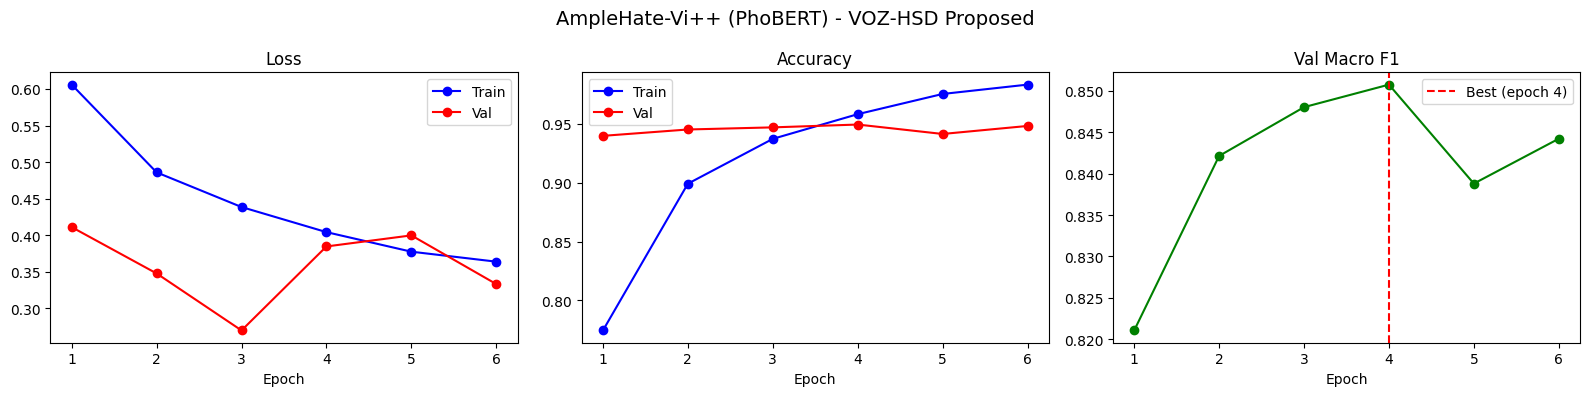

In [22]:
n = len(history['train_loss']); er = range(1, n + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(er, history['train_loss'], 'b-o', label='Train')
axes[0].plot(er, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(er, history['train_acc'], 'b-o', label='Train')
axes[1].plot(er, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[2].plot(er, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')
plt.suptitle(PLOT_TITLE, fontsize=14); plt.tight_layout()
plt.savefig('training_curves_viamplehate_vozhsd.png', dpi=150); plt.show()

In [23]:
ckpt = torch.load(CKPT_NAME, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
threshold = ckpt['threshold']
print(f'Loaded checkpoint: epoch {best_epoch}, threshold={threshold:.2f}')

@torch.no_grad()
def get_predictions(model, loader, threshold):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ids     = batch['input_ids'].to(DEVICE,        non_blocking=PIN_MEMORY)
        heads   = batch['head_token_idx'].to(DEVICE,   non_blocking=PIN_MEMORY)
        attacks = batch['attack_token_idx'].to(DEVICE, non_blocking=PIN_MEMORY)
        hmask   = batch['head_mask'].to(DEVICE,        non_blocking=PIN_MEMORY)
        amask   = batch['attack_mask'].to(DEVICE,      non_blocking=PIN_MEMORY)
        mask    = batch['attention_mask'].to(DEVICE,   non_blocking=PIN_MEMORY)
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits, _ = model(ids, heads, attacks, mask, hmask, amask)
        all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        all_labels.extend(batch['labels'].numpy())
    y_pred = (np.array(all_probs) >= threshold).astype(int)
    return np.array(all_labels), y_pred

y_true, y_pred = get_predictions(model, test_loader, threshold)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

Loaded checkpoint: epoch 4, threshold=0.91
              precision    recall  f1-score   support

    NON-HATE     0.9638    0.9719    0.9678      4487
        HATE     0.7347    0.6803    0.7065       513

    accuracy                         0.9420      5000
   macro avg     0.8492    0.8261    0.8371      5000
weighted avg     0.9403    0.9420    0.9410      5000



Accuracy        : 0.9420   (baseline: 0.9643, Delta=-0.0223)
Macro Precision : 0.8492   (baseline: 0.8159, Delta=+0.0333)
Macro Recall    : 0.8261   (baseline: 0.8211, Delta=+0.0050)
Macro F1        : 0.8371   (baseline: 0.8185, Delta=+0.0186)
F1 (HATE)       : 0.7065   (baseline: 0.6557, Delta=+0.0508)


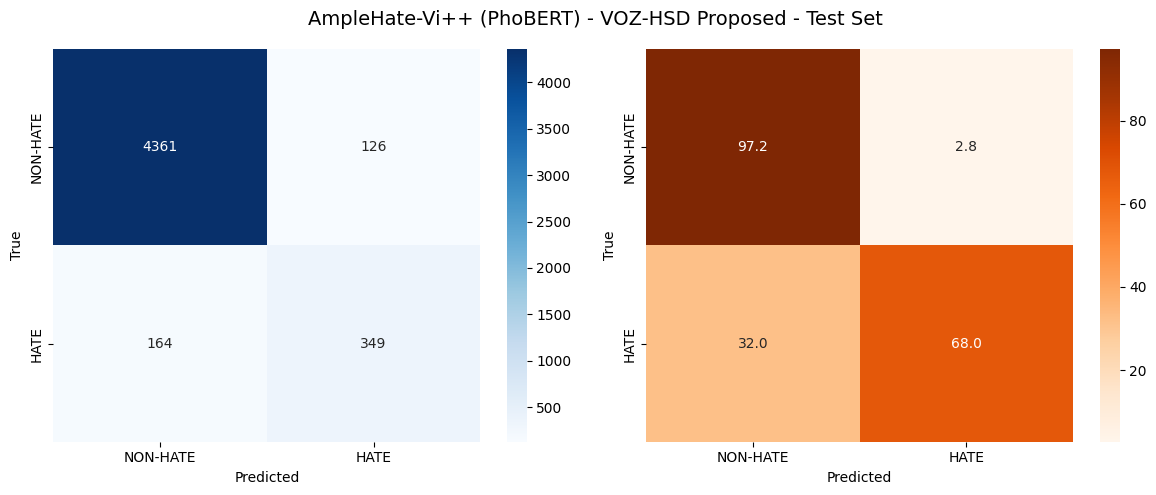

In [24]:
acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
macro_p  = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_r  = recall_score(y_true, y_pred, average='macro',    zero_division=0)
hate_f1  = f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)

print(f"Accuracy        : {acc:.4f}   (baseline: 0.9643, Delta={acc-0.9643:+.4f})")
print(f"Macro Precision : {macro_p:.4f}   (baseline: 0.8159, Delta={macro_p-0.8159:+.4f})")
print(f"Macro Recall    : {macro_r:.4f}   (baseline: 0.8211, Delta={macro_r-0.8211:+.4f})")
print(f"Macro F1        : {macro_f1:.4f}   (baseline: 0.8185, Delta={macro_f1-0.8185:+.4f})")
print(f"F1 (HATE)       : {hate_f1:.4f}   (baseline: 0.6557, Delta={hate_f1-0.6557:+.4f})")

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',   ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
for ax in axes: ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle(PLOT_TITLE + ' - Test Set', fontsize=14); plt.tight_layout()
plt.savefig('confusion_matrix_viamplehate_vozhsd.png', dpi=150); plt.show()


## 17. Test Predict

Quick inference examples using the best checkpoint and validation threshold.


In [25]:
@torch.no_grad()
def predict(texts):
    model.eval()
    results = []
    for text in texts:
        raw = normalize_text(text)
        processed = segment_text(raw)
        token_ids, head_idx, attack_idx, attn_mask = processor_eval.tokenize_and_encode(processed, raw)

        ids     = torch.tensor([token_ids],   dtype=torch.long, device=DEVICE)
        heads   = torch.tensor([head_idx],    dtype=torch.long, device=DEVICE)
        attacks = torch.tensor([attack_idx],  dtype=torch.long, device=DEVICE)
        hmask   = torch.ones((1, len(head_idx)),   dtype=torch.long, device=DEVICE)
        amask   = torch.ones((1, len(attack_idx)), dtype=torch.long, device=DEVICE)
        attn    = torch.tensor([attn_mask],   dtype=torch.long, device=DEVICE)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits, _ = model(ids, heads, attacks, attn, hmask, amask)

        probs   = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        pred_id = int(float(probs[1]) >= threshold)
        results.append({
            'text':  text,
            'label': LABEL_NAMES[pred_id],
            'scores': {LABEL_NAMES[i]: round(float(p), 4) for i, p in enumerate(probs)},
        })
    return results


TEST_CASES = [
    ('Hôm nay trời đẹp quá, đi chơi thôi!',                  'NON-HATE'),
    ('Tụi nó toàn nói nhảm, đúng là quá toxic',               'NON-HATE'),
    ('Đồ ngu, câm miệng lại đi mày',                          'NON-HATE'),
    ('Tao ghét cái loại người như mày, xéo đi cho khuất mắt', 'HATE'),
    ('Cảm ơn bạn đã giúp đỡ mình nhé!',                       'NON-HATE'),
    ('nguyên cả cái tỉnh này không được khôn lắm',            'HATE'),
    ('Bọn đó toàn ăn bám xã hội 🙃',                          'HATE'),
]
correct = 0
for text, expected in TEST_CASES:
    r = predict([text])[0]
    match = 'OK' if r['label'] == expected else 'WRONG'
    correct += int(r['label'] == expected)
    print(f'Input : {text}')
    print(f'Pred  : {r["label"]:<10} {match:<6} {r["scores"]}')
    print()
print(f'Summary: {correct}/{len(TEST_CASES)} ({correct/len(TEST_CASES)*100:.0f}%)')

Input : Hôm nay trời đẹp quá, đi chơi thôi!
Pred  : NON-HATE   OK     {'NON-HATE': 0.7656, 'HATE': 0.2346}

Input : Tụi nó toàn nói nhảm, đúng là quá toxic
Pred  : HATE       WRONG  {'NON-HATE': 0.0072, 'HATE': 0.9927}

Input : Đồ ngu, câm miệng lại đi mày
Pred  : HATE       WRONG  {'NON-HATE': 0.0046, 'HATE': 0.9956}

Input : Tao ghét cái loại người như mày, xéo đi cho khuất mắt
Pred  : HATE       OK     {'NON-HATE': 0.0121, 'HATE': 0.9878}

Input : Cảm ơn bạn đã giúp đỡ mình nhé!
Pred  : NON-HATE   OK     {'NON-HATE': 0.7808, 'HATE': 0.2191}

Input : nguyên cả cái tỉnh này không được khôn lắm
Pred  : HATE       OK     {'NON-HATE': 0.0128, 'HATE': 0.9873}

Input : Bọn đó toàn ăn bám xã hội 🙃
Pred  : HATE       OK     {'NON-HATE': 0.0057, 'HATE': 0.9941}

Summary: 5/7 (71%)


In [26]:
os.makedirs('outputs', exist_ok=True)
config = {
    'notebook'             : 'vozhsd-viamplehate-phobert-proposed',
    'dataset'              : 'VOZ-HSD (100k stratified from tarudesu/VOZ-HSD)',
    'method'               : 'AmpleHate-Vi++ (Viet NER + target/attack cues + adaptive gate)',
    'encoder'              : MODEL_NAME,
    'ner_model'            : NER_MODEL,
    'sample_size'          : int(SAMPLE_SIZE),
    'random_state'         : int(RANDOM_STATE),
    'max_len'              : MAX_LEN,
    'hidden_dim'           : HIDDEN_DIM,
    'grad_accum'           : GRAD_ACCUM,
    'alpha_cl'             : ALPHA_CL,
    'use_ner_at_eval'      : USE_NER_AT_EVAL,
    'dropout'              : DROPOUT,
    'num_classes'          : NUM_CLASSES,
    'label_names'          : LABEL_NAMES,
    'lr_encoder'           : float(LR),
    'lr_head'              : float(HEAD_LR),
    'best_epoch'           : int(best_epoch),
    'best_val_f1'          : round(float(best_f1), 4),
    'best_threshold'       : round(float(threshold), 2),
    'test_accuracy'        : round(float(acc), 4),
    'test_macro_f1'        : round(float(macro_f1), 4),
    'test_macro_p'         : round(float(macro_p), 4),
    'test_macro_r'         : round(float(macro_r), 4),
    'test_f1_hate'         : round(float(hate_f1), 4),
    'baseline_macro_f1'    : 0.8185,
    'baseline_hate_f1'     : 0.6557,
    'delta_macro_f1'       : round(float(macro_f1) - 0.8185, 4),
    'delta_hate_f1'        : round(float(hate_f1)  - 0.6557, 4),
}
with open('outputs/viamplehate_vozhsd_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(json.dumps(config, indent=2, ensure_ascii=False))


{
  "notebook": "vozhsd-viamplehate-phobert-proposed",
  "dataset": "VOZ-HSD (100k stratified from tarudesu/VOZ-HSD)",
  "method": "AmpleHate-Vi++ (Viet NER + target/attack cues + adaptive gate)",
  "encoder": "vinai/phobert-base",
  "ner_model": "NlpHUST/ner-vietnamese-electra-base",
  "sample_size": 40000,
  "random_state": 42,
  "max_len": 256,
  "hidden_dim": 768,
  "grad_accum": 2,
  "alpha_cl": 0.1,
  "use_ner_at_eval": true,
  "dropout": 0.1,
  "num_classes": 2,
  "label_names": [
    "NON-HATE",
    "HATE"
  ],
  "lr_encoder": 2e-05,
  "lr_head": 5e-05,
  "best_epoch": 4,
  "best_val_f1": 0.8508,
  "best_threshold": 0.91,
  "test_accuracy": 0.942,
  "test_macro_f1": 0.8371,
  "test_macro_p": 0.8492,
  "test_macro_r": 0.8261,
  "test_f1_hate": 0.7065,
  "baseline_macro_f1": 0.8185,
  "baseline_hate_f1": 0.6557,
  "delta_macro_f1": 0.0186,
  "delta_hate_f1": 0.0508
}
